In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('istanbul_stock_exchange.csv')
df.head()

,date,TL BASED ISE,USD BASED ISE,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
0,5-Jan-09,0.035754,0.038376,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
1,6-Jan-09,0.025426,0.031813,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2,7-Jan-09,-0.028862,-0.026353,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
3,8-Jan-09,-0.062208,-0.084716,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
4,9-Jan-09,0.009860,0.009658,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802


In [12]:
df.shape

(536, 10)

col meanings:

* TL based ISE - Istanbul Stock Exchange Return
* TL based USD - Istanbul Stock Exchange Return in USD
* SP - S&P500 index
* DAX - German stock index
* FTSE - UK stock index
* NIKKEI - Japanese stock index
* BOVESPA - Brazilian stock index
* EU - European stock index
* EM - Emerging markets

In [13]:
df.columns

Index(['date', 'TL BASED ISE', 'USD BASED ISE', 'SP', 'DAX', 'FTSE', 'NIKKEI',
       'BOVESPA', 'EU', 'EM'],
      dtype='object')

In [14]:
df = df.rename(columns={'USD BASED ISE': 'USD'})
df

,date,TL BASED ISE,USD,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
0,5-Jan-09,0.035754,0.038376,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
1,6-Jan-09,0.025426,0.031813,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2,7-Jan-09,-0.028862,-0.026353,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
3,8-Jan-09,-0.062208,-0.084716,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
4,9-Jan-09,0.009860,0.009658,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802
...,...,...,...,...,...,...,...,...,...,...
531,16-Feb-11,0.008599,0.013400,0.006238,0.001925,0.007952,0.005717,0.018371,0.006975,0.003039
532,17-Feb-11,0.009310,0.015977,0.003071,-0.001186,0.000345,0.002620,0.001686,-0.000581,0.001039
533,18-Feb-11,0.000191,-0.001653,0.001923,0.002872,-0.000723,0.000568,0.005628,0.000572,0.006938
534,21-Feb-11,-0.013069,-0.013706,-0.020742,-0.014239,-0.011275,0.001358,-0.011942,-0.012615,-0.000958


<Axes: >

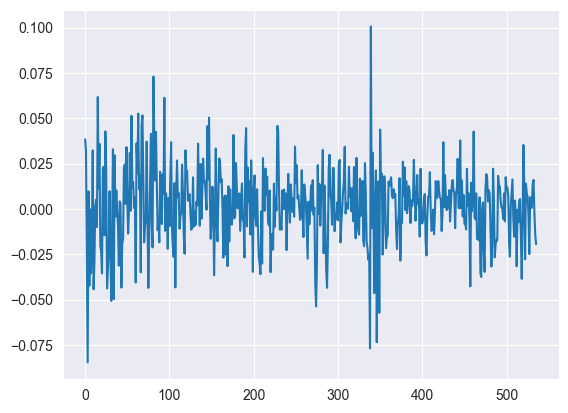

In [15]:
df['USD'].plot()

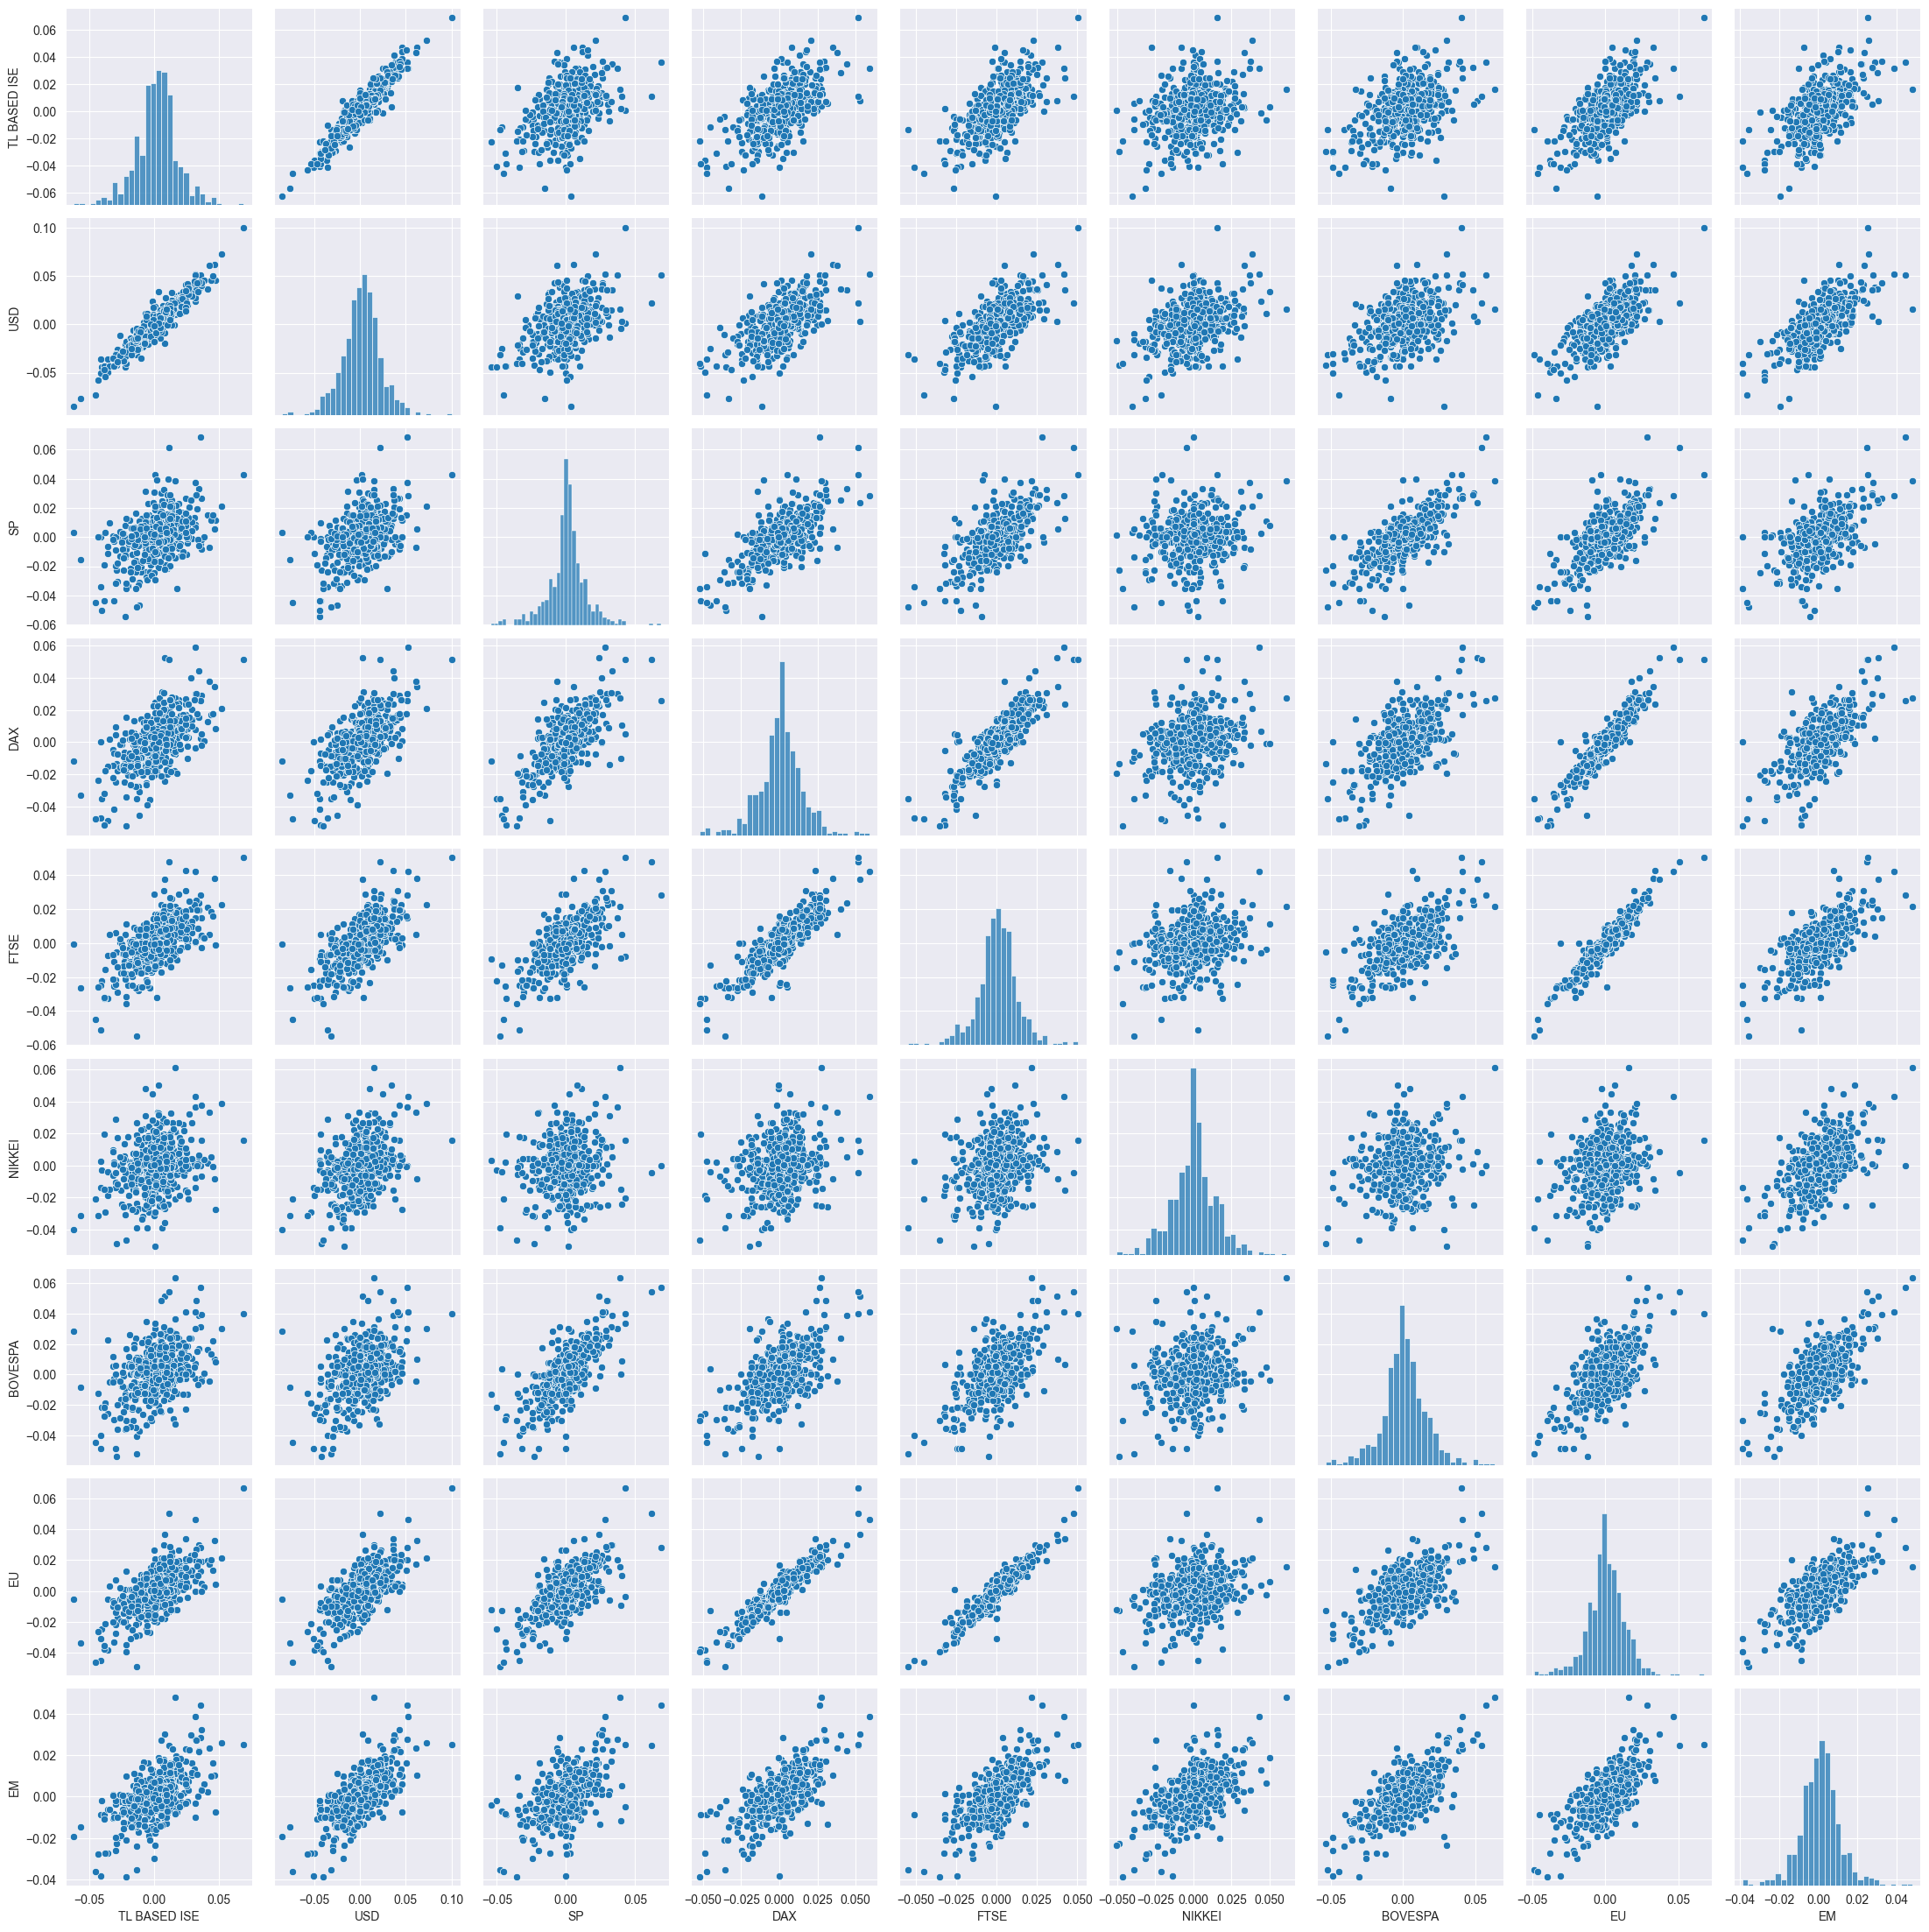

In [16]:
sns.pairplot(df)

<Axes: >

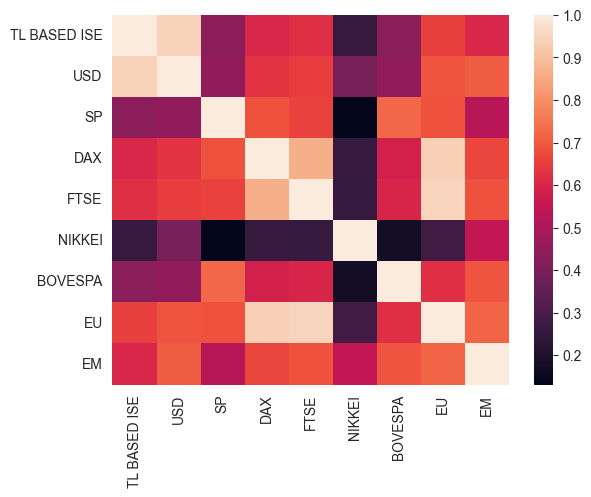

In [17]:
sns.heatmap(df.select_dtypes('number').corr())

In [18]:
import statsmodels.api as sm

X = df[['USD', 'SP', 'DAX', 'FTSE', 'NIKKEI', 'BOVESPA',
       'EU', 'EM']]
X = X.iloc[:-1, :].reset_index(drop=True)
X = sm.add_constant(X)
y = df[['USD']].iloc[1:].dropna().reset_index(drop=True)

print("df shapes:", X.shape, y.shape)
model = sm.OLS(y, X)
model1 = model.fit()

print(model1.summary())

df shapes: (535, 9) (535, 1)
                            OLS Regression Results                            
Dep. Variable:                    USD   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     13.95
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           1.83e-18
Time:                        21:53:58   Log-Likelihood:                 1357.6
No. Observations:                 535   AIC:                            -2697.
Df Residuals:                     526   BIC:                            -2659.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012  

In [19]:
model2 = model.fit_regularized(method='elastic_net', alpha=0.0001, L1_wt=1)
print(model2.params)

const      0.001370
USD        0.000000
SP         0.000000
DAX        0.000000
FTSE       0.000000
NIKKEI     0.000000
BOVESPA    0.013641
EU         0.000000
EM         0.000000
dtype: float64


L1 regularisation believes Brazilian stock exchange is only one worth doing

In [20]:
X = df[['USD', 'SP', 'NIKKEI', 'BOVESPA',
       'EU', 'EM']]
X = X.iloc[:-1, :].reset_index(drop=True)
X = sm.add_constant(X)
y = df[['USD']].iloc[1:].dropna().reset_index(drop=True)

print("df shapes:", X.shape, y.shape)
model = sm.OLS(y, X)
model1 = model.fit()

print(model1.summary())

df shapes: (535, 7) (535, 1)
                            OLS Regression Results                            
Dep. Variable:                    USD   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     18.65
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           1.03e-19
Time:                        21:53:58   Log-Likelihood:                 1357.5
No. Observations:                 535   AIC:                            -2701.
Df Residuals:                     528   BIC:                            -2671.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012  

<Figure size 1600x1200 with 0 Axes>

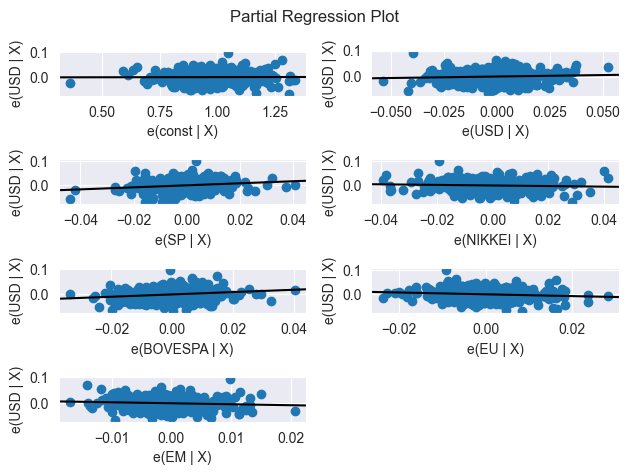

In [21]:
from statsmodels.graphics.regressionplots import plot_partregress_grid

fig = plt.figure(figsize=(16, 12))
plot_partregress_grid(model1)
plt.tight_layout()
plt.show()

In [22]:
X = X.drop('const', axis =1)

In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

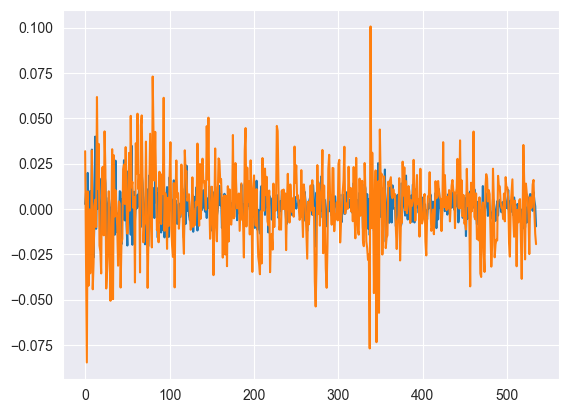

In [24]:
plt.plot(y_pred)
plt.plot(y)

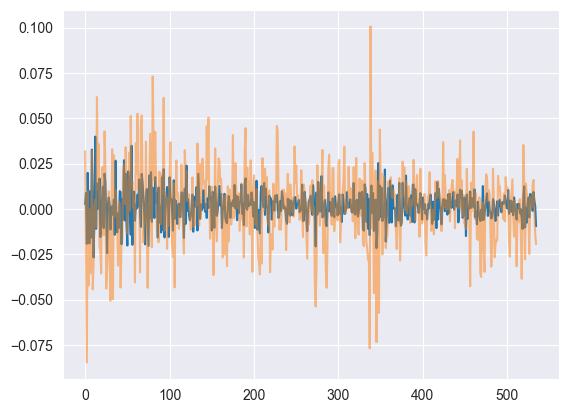

In [25]:
plt.plot(y_pred)
plt.plot(y, alpha=0.5)

In [26]:
# able to account for osme variance

lr.coef_

array([[ 0.11369508,  0.4144226 , -0.11798224,  0.45838474, -0.36988982,
        -0.36880535]])

In [27]:
X.shape
535*0.7

374.5

In [28]:
import xgboost as xgb


In [29]:
X = df[['USD', 'SP', 'NIKKEI', 'BOVESPA',
       'EU', 'EM']]
X = X.iloc[:-1, :].reset_index(drop=True)
y = df[['USD']].iloc[1:].dropna().reset_index(drop=True)


split = int(len(X) * 0.7)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

gb = xgb.XGBRegressor()
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

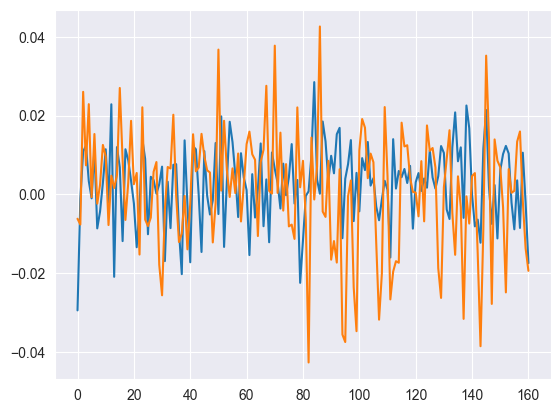

In [34]:
pred = pd.Series(y_pred)
pred.plot()
plt.plot(y_test.reset_index(drop=True))